In [ ]:
%load_ext autoreload
%autoreload 2

# Tes imports normaux en dessous
import numpy as np
import matplotlib.pyplot as plt
from ols_model import fit_ols, predict_ols

import numpy as np
import matplotlib.pyplot as plt

# Importation des fonctions du fichier ols_model.py
from ols_model import fit_ols, predict_ols


rng = np.random.default_rng(seed=42)
n_samples = 100
n_features = 2

# Génération de X et de la cible Y avec un bruit gaussien
X = rng.standard_normal((n_samples, n_features))
true_beta = np.array([[4.5], [3.0], [1.2]])

X_b = np.hstack((np.ones((n_samples, 1)), X))
Y = X_b @ true_beta + rng.standard_normal((n_samples, 1))

print("Données générées avec succès via default_rng() !")
print("Forme de X :", X.shape)
print("Forme de Y :", Y.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Données générées avec succès via default_rng() !
Forme de X : (100, 2)
Forme de Y : (100, 1)


In [2]:
# Calcul des coefficients beta estimés
beta_estime = fit_ols(X, Y, fit_intercept=True)

print("--- COMPARAISON ---")
print("Coefficients d'origine (théoriques) :")
print(true_beta.flatten())

print("\nCoefficients retrouvés par notre modèle stable :")
print(beta_estime.flatten())

--- COMPARAISON ---
Coefficients d'origine (théoriques) :
[4.5 3.  1.2]

Coefficients retrouvés par notre modèle stable :
[4.4362371  2.85679922 1.2148202 ]


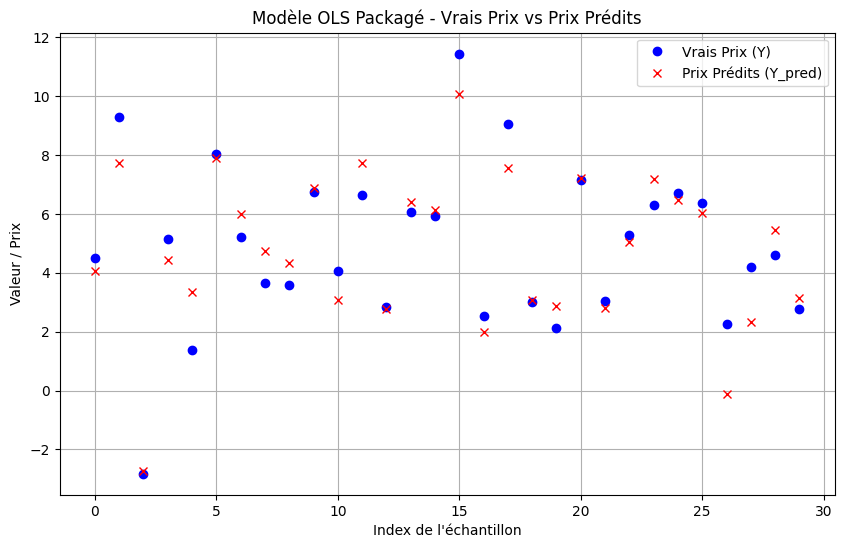

In [3]:
# Calcul des prix prédits
Y_pred = predict_ols(X, beta_estime, fit_intercept=True)

# Tracé pour les 30 premiers points
plt.figure(figsize=(10, 6))
plt.plot(Y[:30], label="Vrais Prix (Y)", marker='o', color='blue', linestyle='none')
plt.plot(Y_pred[:30], label="Prix Prédits (Y_pred)", marker='x', color='red', linestyle='none')

plt.title("Modèle OLS Packagé - Vrais Prix vs Prix Prédits")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Valeur / Prix")
plt.legend()
plt.grid(True)
plt.show()

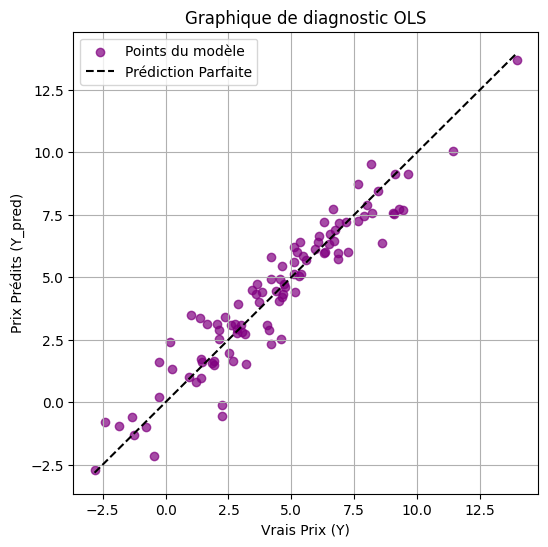

In [5]:
plt.figure(figsize=(6, 6))
# On trace les vrais prix en X et les prix prédits en Y
plt.scatter(Y, Y_pred, color='purple', alpha=0.7, label='Points du modèle')

# On trace la diagonale parfaite (Y = Y_pred)
parfaite_diagonale = [Y.min(), Y.max()]
plt.plot(parfaite_diagonale, parfaite_diagonale, color='black', linestyle='--', label='Prédiction Parfaite')

plt.title("Graphique de diagnostic OLS")
plt.xlabel("Vrais Prix (Y)")
plt.ylabel("Prix Prédits (Y_pred)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
"""
A retenir
""" 

# 1. Ne pas utiliser np.random.seed() (Le piège de l'état global)
# --> Cette méthode est dite "legacy" (obsolète) dans NumPy
# --> Elle modifie l'état aléatoire global de toute ton application Python. 
# --> Si un autre script s'exécute en parallèle sur le même serveur, les deux codes vont interférer, brisant la reproductibilité.

# Solution :
# np.random.default_rng()
# --> plus rapide, plus sûr, et cela isole tes simulations 
# --> indispensable pour les simulations de Monte Carlo massives


# 2. Privilégier la clarté de construction matricielle plutôt que les raccourcis syntaxiques
# --> Le problème en production : np.c_ (et son jumeau np.r_) 

# Solution : 
# np.hstack() (horizontal stack) ou np.concatenate()
# --> Le code devient immédiatement auto-documenté.


# 3. Ne jamais inverser une matrice avec np.linalg.inv()
# --> opération lourde et numériquement instable (surtout si mauvais conditionnement)
# --> erreurs d'arrondi qui peuvent faire planter le code

# Solution : 
# A = X_t @ X_b
# b = X_t @ Y
# return np.linalg.solve(A, b)
# --> Utilise décomposition LU, Cholesky
# --> beaucoup plus stable et rapide


# 4. Lisibilité des opérations matricielles
# Utiliser l'opérateur @
# --> au lieu de A.dot(B).dot(C), on écrit A @ B @ C